# **Notebook 2: Data Preparation**
## Assignment: Hybrid RAG & Fine-Tuning for Customer Support
---

### TO-DO: Before Running This Notebook

**Files you NEED:**
- [ ] `sampled_data.csv` — Created by Notebook 1
- [ ] `corporate_policies/` folder with `.md` SOP files
- [ ] Internet access (to download the tokenizer)

**Files this notebook will CREATE:**
- [ ] `./tokenized_train/`, `./tokenized_valid/`, `./tokenized_test/` — HuggingFace datasets _(Required by NB6)_
- [ ] `df_test.csv` — Test set with readable text + labels _(Required by NB5 and NB7)_

---

## **Stage 2: Data Preparation**
### **Task 2.1: Clean and Validate Dataset**

#### **2.1.1 Remove Duplicate and Invalid Records [2 marks]**
**The Task:** Identify and remove duplicate records using normalised deduplication (lowercase + strip before comparison), plus any invalid, incomplete, or corrupted records.

**Hints & Tips:**
* Load `sampled_data.csv` from Notebook 1 first.
* Normalised dedup: create a temporary `_norm` column = `instruction.str.lower().str.strip()`, drop duplicates on it, then drop the helper column.
* Check for nulls in `instruction`, `intent`, and `category` — drop rows missing any of these targets.
* Print the number of rows removed so the cleaning is auditable.

**Why we are doing it:** To prevent degraded training from redundant or broken records, and to stop near-duplicates leaking across train/test splits later.
**How we are doing it:** Pandas normalised deduplication and null filtering.

**Learner Inference:** Exact-match dedup misses `"Where is my order?"` vs `"where is my order?"`. Normalising first catches these and keeps your splits clean.

In [1]:
import pandas as pd

df = pd.read_csv("sampled_data.csv")
print(f"Loaded sampled_data.csv: {len(df)} rows")

before = len(df)

# Normalised deduplication: lowercase + strip BEFORE drop_duplicates
df["_norm"] = df["instruction"].str.lower().str.strip()
n_dupes = df.duplicated(subset="_norm").sum()
df = df.drop_duplicates(subset="_norm").drop(columns="_norm").reset_index(drop=True)
print(f"Removed {n_dupes} normalised duplicate records")

before_null = len(df)
df = df.dropna(subset=["instruction", "intent", "category"]).reset_index(drop=True)
df = df[
    (df["instruction"].str.strip().str.len() > 0)
    & (df["intent"].str.strip().str.len() > 0)
    & (df["category"].str.strip().str.len() > 0)
].reset_index(drop=True)
print(f"Removed {before_null - len(df)} invalid/incomplete/corrupted records")

print(f"\nTotal removed: {before - len(df)} | Remaining valid rows: {len(df)}")
assert 1000 <= len(df) <= 5000, "Cleaned dataset must remain within the 1,000-5,000 valid-record range."


Loaded sampled_data.csv: 1488 rows
Removed 0 normalised duplicate records
Removed 0 invalid/incomplete/corrupted records

Total removed: 0 | Remaining valid rows: 1488


#### **2.1.2 Standardise Dataset Formatting [2 marks]**
**The Task:** Clean the strings inside `instruction`, `intent`, and `category` by stripping whitespace and enforcing uniform casing (intents = lower, categories = upper).

**Hints & Tips:**
* Use Pandas `.str.strip()`, `.str.lower()`, `.str.upper()`.
* Always strip whitespace BEFORE lowering — trailing spaces survive `.lower()`.
* Standardised casing prevents the model treating "Refund" and "refund" as different classes.

**Why we are doing it:** To ensure raw strings are perfectly standardised before injecting them into prompt templates.
**How we are doing it:** Pandas string manipulation.

**Learner Inference:** Standardising capitalisation prevents the model from treating the same intent written two ways as two separate classes.

In [2]:
# Standardise: strip whitespace BEFORE casing (trailing spaces survive .lower()/.upper())
df["instruction"] = df["instruction"].str.strip()
df["intent"] = df["intent"].str.strip().str.lower()
df["category"] = df["category"].str.strip().str.upper()

print(df[["instruction", "intent", "category"]].head())
print(f"\nUnique intents (lowercase): {df['intent'].nunique()}")
print(f"Unique categories (UPPERCASE): {df['category'].nunique()}")
print(f"Categories: {sorted(df['category'].unique())}")


                                         instruction  \
0                   I can't talk with  a human agent   
1  I have got to locate hte bills from {{Person N...   
2  I cannot pay, help me to inform of a problem w...   
3           I want help speaking to customer service   
4           I try to see th accepted payment options   

                     intent category  
0       contact_human_agent  CONTACT  
1             check_invoice  INVOICE  
2             payment_issue  PAYMENT  
3  contact_customer_service  CONTACT  
4     check_payment_methods  PAYMENT  

Unique intents (lowercase): 27
Unique categories (UPPERCASE): 11
Categories: ['ACCOUNT', 'CANCEL', 'CONTACT', 'DELIVERY', 'FEEDBACK', 'INVOICE', 'ORDER', 'PAYMENT', 'REFUND', 'SHIPPING', 'SUBSCRIPTION']


### **Task 2.2: Create Instruction-Tuning Dataset**

#### **2.2.1 Transform Records into Instruction Format [2 marks]**
**The Task:** Wrap the raw instructions and targets into a standardized `ChatML` format, forcing the assistant's response to be a strict JSON string containing the `intent` and `category`.

**Hints & Tips:**
* Use the Qwen tokenizer's `apply_chat_template(tokenize=False)`.
* The target JSON is `{"intent": "...", "category": "..."}` — built via `json.dumps()`.

**Model Selection:**
* **Qwen/Qwen2.5-1.5B-Instruct** (recommended) — fits T4, strong instruction following.
* **TinyLlama-1.1B-Chat** — lighter but weaker at structured output.
* **Llama-3-8B-Instruct** — best quality, needs >16GB VRAM even in 4-bit.
* Whatever you pick, set `MODEL_ID` here and in ALL later notebooks.

**Learner Inference:** Formatting the target as JSON establishes the exact structural rules the LoRA model learns to mimic in Stage 4.

In [3]:
import json
from transformers import AutoTokenizer

# Same MODEL_ID must be used in every later notebook (Baseline, RAG, Fine-Tuning, V2 eval).
MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

ROUTER_SYSTEM_PROMPT = (
    "You are a customer support intent router. Given a customer message, respond with a single "
    "JSON object containing exactly two fields: \"intent\" and \"category\". Output JSON only, "
    "with no explanation."
)

def to_chatml(row):
    target = json.dumps({"intent": row["intent"], "category": row["category"]})
    messages = [
        {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
        {"role": "user", "content": row["instruction"]},
        {"role": "assistant", "content": target},
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False)
    return text, target

chatml_texts, targets = [], []
for _, row in df.iterrows():
    text, target = to_chatml(row)
    chatml_texts.append(text)
    targets.append(target)

df["text"] = chatml_texts
df["target_json"] = targets

print("Example ChatML-formatted record:\n")
print(df["text"].iloc[0])


Example ChatML-formatted record:

<|im_start|>system
You are a customer support intent router. Given a customer message, respond with a single JSON object containing exactly two fields: "intent" and "category". Output JSON only, with no explanation.<|im_end|>
<|im_start|>user
I can't talk with  a human agent<|im_end|>
<|im_start|>assistant
{"intent": "contact_human_agent", "category": "CONTACT"}<|im_end|>



#### **2.2.2 Validate Instruction Templates [2 marks]**
**The Task:** Extract the assistant's portion of the generated ChatML string and parse it with `json.loads()` to verify structural integrity.

**Hints & Tips:**
* Split the string by `<|im_start|>assistant` and parse what follows.
* If this throws `JSONDecodeError`, your formatting in 2.2.1 is broken — fix before training.
* Validate several samples, not just the first.

**Learner Inference:** A JSONDecodeError here means the model would learn broken syntax. Catching it now saves a failed training run.

In [4]:
import random

random.seed(42)
sample_idx = random.sample(range(len(df)), min(50, len(df)))

n_valid = 0
failures = []
for i in sample_idx:
    full_text = df["text"].iloc[i]
    assistant_part = full_text.split("<|im_start|>assistant")[-1]
    assistant_part = assistant_part.replace("<|im_end|>", "").strip()
    try:
        parsed = json.loads(assistant_part)
        assert set(parsed.keys()) == {"intent", "category"}, "unexpected keys"
        n_valid += 1
    except Exception as e:
        failures.append((i, assistant_part, str(e)))

print(f"{n_valid}/{len(sample_idx)} sampled ChatML templates parsed as valid JSON with exactly {{intent, category}} keys.")
if failures:
    print("\nFailures:")
    for i, txt, err in failures[:5]:
        print(f" - row {i}: {err} -> {txt!r}")

assert n_valid == len(sample_idx), "ChatML/JSON template validation failed for some rows — fix formatting before proceeding."
print("\nAll sampled templates are schema-compliant.")


50/50 sampled ChatML templates parsed as valid JSON with exactly {intent, category} keys.

All sampled templates are schema-compliant.


### **Task 2.3: Engineer Training and Retrieval Data**

#### **2.3.1 Tokenise Dataset [2 marks]**
**The Task:** Convert text sequences into tensor IDs and apply `-100` masking to padding tokens in the `labels` array.

**Hints & Tips:**
* If a token equals `tokenizer.pad_token_id`, replace it with `-100` in labels.
* `-100` is PyTorch's ignore index — the loss skips these tokens.

**Parameter Tuning:**
* `max_length`: `128` (fast, fits most Bitext prompts), `256` (safer if truncation seen), `64` (too aggressive).

**Learner Inference:** Masking isolates the loss — the model is penalised for wrong JSON, not for padding.

In [5]:
from datasets import Dataset

MAX_LENGTH = 128  # see Task 2.3.2 for the truncation-risk analysis behind this choice

ASSISTANT_MARKER_IDS = tokenizer("<|im_start|>assistant\n", add_special_tokens=False)["input_ids"]

def find_assistant_start(input_ids):
    """Index of the first token AFTER the '<|im_start|>assistant\\n' marker, or None if absent (truncated)."""
    n = len(ASSISTANT_MARKER_IDS)
    for i in range(len(input_ids) - n + 1):
        if input_ids[i:i + n] == ASSISTANT_MARKER_IDS:
            return i + n
    return None

def tokenize_batch(examples):
    input_ids_list, attn_list, labels_list = [], [], []
    for text in examples["text"]:
        enc = tokenizer(text, truncation=True, max_length=MAX_LENGTH, padding="max_length")
        input_ids = enc["input_ids"]
        labels = list(input_ids)
        assistant_start = find_assistant_start(input_ids)
        for i in range(len(labels)):
            if input_ids[i] == tokenizer.pad_token_id:
                # -100 is PyTorch's ignore_index: loss skips padding tokens
                labels[i] = -100
            elif assistant_start is not None and i < assistant_start:
                # Also mask the system+user prompt tokens: the router should only be
                # penalised for the JSON it generates, not for reproducing the prompt.
                labels[i] = -100
        input_ids_list.append(input_ids)
        attn_list.append(enc["attention_mask"])
        labels_list.append(labels)
    return {"input_ids": input_ids_list, "attention_mask": attn_list, "labels": labels_list}

hf_dataset = Dataset.from_pandas(df[["text", "intent", "category", "instruction", "target_json"]])
hf_dataset = hf_dataset.map(tokenize_batch, batched=True, batch_size=32)

print(hf_dataset)
print("\nFirst row — input_ids[:15]:", hf_dataset[0]["input_ids"][:15])
print("First row — labels[:15]   :", hf_dataset[0]["labels"][:15], "(-100 = masked)")
n_masked = sum(1 for l in hf_dataset[0]["labels"] if l == -100)
print(f"Masked tokens in row 0: {n_masked}/{MAX_LENGTH}")


Map:   0%|          | 0/1488 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'intent', 'category', 'instruction', 'target_json', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 1488
})

First row — input_ids[:15]: [151644, 8948, 198, 2610, 525, 264, 6002, 1824, 7385, 9273, 13, 16246, 264, 6002, 1943]
First row — labels[:15]   : [-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100] (-100 = masked)
Masked tokens in row 0: 112/128


#### **2.3.2 Analyse Token Distributions [2 marks]**
**The Task:** Analyse the token-count distribution to detect truncation risks and verify the sequence-length configuration.

**Hints & Tips:**
* Count non-padding tokens per row and plot a histogram.
* If >5% of rows hit `max_length`, increase it.
* The JSON target is ~20 tokens — if truncated, the model learns incomplete output.

**Learner Inference:** Sequences hitting the ceiling mean the JSON target is getting cut off, teaching the model to produce broken output.

Token-count distribution (non-padding tokens per row):


count    1488.000000
mean       78.346102
std         3.100725
min        70.000000
25%        76.000000
50%        78.000000
75%        80.000000
max        90.000000
dtype: float64

Rows hitting max_length=128 (truncation risk): 0 (0.00%)


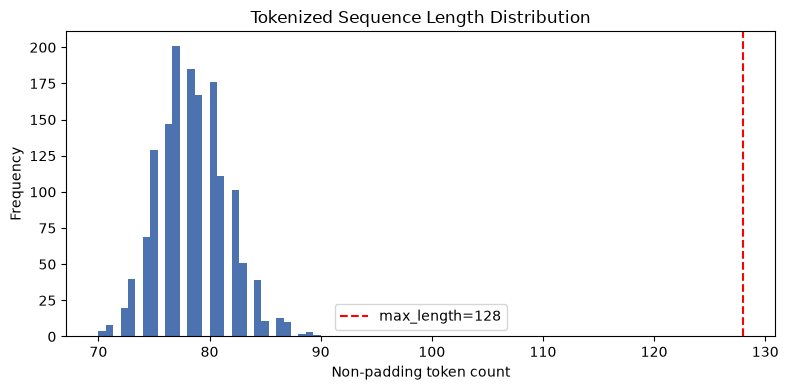

Truncation risk acceptable (<5%) — MAX_LENGTH=128 is sufficient for this dataset.


In [6]:
import numpy as np
import matplotlib.pyplot as plt

token_counts = np.array([
    sum(1 for t in ids if t != tokenizer.pad_token_id) for ids in hf_dataset["input_ids"]
])

print("Token-count distribution (non-padding tokens per row):")
print(pd.Series(token_counts).describe())

n_truncated = int((token_counts >= MAX_LENGTH).sum())
pct_truncated = n_truncated / len(token_counts) * 100
print(f"\nRows hitting max_length={MAX_LENGTH} (truncation risk): {n_truncated} ({pct_truncated:.2f}%)")

plt.figure(figsize=(8, 4))
plt.hist(token_counts, bins=30, color="#4c72b0")
plt.axvline(MAX_LENGTH, color="red", linestyle="--", label=f"max_length={MAX_LENGTH}")
plt.xlabel("Non-padding token count")
plt.ylabel("Frequency")
plt.title("Tokenized Sequence Length Distribution")
plt.legend()
plt.tight_layout()
plt.savefig("token_length_distribution.png", dpi=100)
plt.show()

if pct_truncated > 5:
    print("WARNING: >5% of rows are truncated — increase MAX_LENGTH and re-tokenise.")
else:
    print(f"Truncation risk acceptable (<5%) — MAX_LENGTH={MAX_LENGTH} is sufficient for this dataset.")


#### **2.3.3 Prepare Retrieval Corpus [3 marks]**
**The Task:** Ingest the Markdown SOPs into LangChain Document objects ready to be embedded.

**Hints & Tips:**
* Use `TextLoader` from LangChain.
* Each `.md` file becomes one `Document` with `.page_content` and `.metadata`.
* These documents are embedded into ChromaDB in Notebook 4.

**Learner Inference:** These document objects form the knowledge base your bot retrieves from in Stages 3 and 4.

In [7]:
import glob
from langchain_community.document_loaders import TextLoader

SOP_DIR = "Dataset/sop_documents"
sop_files = sorted(glob.glob(f"{SOP_DIR}/*.md"))

retrieval_docs = []
for f in sop_files:
    loader = TextLoader(f, encoding="utf-8")
    docs = loader.load()
    for d in docs:
        d.metadata["source_file"] = f.split("/")[-1]
    retrieval_docs.extend(docs)

print(f"Loaded {len(retrieval_docs)} retrieval-ready documents from {len(sop_files)} SOP files.")
for d in retrieval_docs[:2]:
    print("\n---")
    print("metadata:", d.metadata)
    print(d.page_content[:200], "...")

# Corpus quality validation
empty_docs = [d for d in retrieval_docs if len(d.page_content.strip()) == 0]
word_counts = [len(d.page_content.split()) for d in retrieval_docs]
print(f"\nEmpty documents: {len(empty_docs)}")
print(f"Word-count per document — min: {min(word_counts)}, max: {max(word_counts)}, mean: {np.mean(word_counts):.1f}")
assert len(empty_docs) == 0, "Found empty SOP documents — corpus quality check failed."
print("Retrieval corpus quality validated: no empty documents.")


/var/folders/mk/56820dv57jz3kwjfc7566dh40000gn/T/ipykernel_58883/714086380.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


Loaded 13 retrieval-ready documents from 13 SOP files.

---
metadata: {'source': 'Dataset/sop_documents/account_recovery.md', 'source_file': 'account_recovery.md'}
# Account Recovery

## When To Use
Use this procedure when a customer cannot access their account due to a
lockout, a lost email address, suspected unauthorized access, or a disabled
account — anythin ...

---
metadata: {'source': 'Dataset/sop_documents/billing_disputes.md', 'source_file': 'billing_disputes.md'}
# Billing Disputes

## Scope
Use this when a customer questions a charge: an amount they do not recognize,
a charge larger than expected, a duplicate charge, or a charge after they
believed a service  ...

Empty documents: 0
Word-count per document — min: 228, max: 280, mean: 247.2
Retrieval corpus quality validated: no empty documents.


### **Task 2.4: Create Dataset Partitions**

#### **2.4.1 Create Train, Validation, and Test Splits [5 marks]**
**The Task:** Split the tokenized dataset into Train (80%), Validation (10%), and Test (10%) partitions using stratified sampling. Demonstrate zero data leakage across all three.

**Hints & Tips:**
* Use `train_test_split` from sklearn with `stratify=df['intent']` so every intent appears in all splits.
* Split twice: first 80/20, then split the 20% into 50/50 (giving 10%/10%).
* The validation set is not optional — it is actively used during fine-tuning (Stage 4 / Notebook 6) for loss monitoring and early stopping.
* The test set must stay completely independent — used only for final evaluation.
* Verify zero overlap with set-intersection checks: `assert len(train_set & test_set) == 0`.
* Build a `df_test` DataFrame preserving readable `text`/`intent`/`category` columns for later scoring.

**Parameter Tuning:**
* Split ratio: `80/10/10` (recommended) or `70/15/15`. Any alternative must be justified.

**Why we are doing it:** To guarantee isolated, unseen data for unbiased evaluation, and a validation set for overfitting detection.
**How we are doing it:** Stratified sklearn splits with explicit programmatic leakage verification.

**Learner Inference:** Testing on data the model trained on gives false confidence (leakage). The held-out test split proves your model handles completely new phrasing; the validation split tells you when to stop training.

In [8]:
from sklearn.model_selection import train_test_split

indices = np.arange(len(df))

# 80/10/10: first split off 80% train, then split the remaining 20% evenly into valid/test
train_idx, temp_idx = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=df["intent"]
)
valid_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=42, stratify=df["intent"].iloc[temp_idx]
)

print(f"Train: {len(train_idx)} | Valid: {len(valid_idx)} | Test: {len(test_idx)}")
print(f"Train %: {len(train_idx)/len(df)*100:.1f}  Valid %: {len(valid_idx)/len(df)*100:.1f}  Test %: {len(test_idx)/len(df)*100:.1f}")

all_intents = set(df["intent"])
train_intents = set(df["intent"].iloc[train_idx])
valid_intents = set(df["intent"].iloc[valid_idx])
test_intents = set(df["intent"].iloc[test_idx])
print(f"\nAll intents present in train: {all_intents <= train_intents}")
print(f"All intents present in valid: {all_intents <= valid_intents}")
print(f"All intents present in test:  {all_intents <= test_intents}")

# Leakage verification via normalised set-intersection checks
train_prompts = set(df["instruction"].iloc[train_idx].str.lower().str.strip())
valid_prompts = set(df["instruction"].iloc[valid_idx].str.lower().str.strip())
test_prompts = set(df["instruction"].iloc[test_idx].str.lower().str.strip())

overlap_train_valid = train_prompts & valid_prompts
overlap_train_test = train_prompts & test_prompts
overlap_valid_test = valid_prompts & test_prompts

assert len(overlap_train_valid) == 0, f"Leakage between train/valid: {overlap_train_valid}"
assert len(overlap_train_test) == 0, f"Leakage between train/test: {overlap_train_test}"
assert len(overlap_valid_test) == 0, f"Leakage between valid/test: {overlap_valid_test}"
print("\nZero leakage confirmed via set-intersection checks across all three independent partitions.")

hf_train = hf_dataset.select(train_idx)
hf_valid = hf_dataset.select(valid_idx)
hf_test = hf_dataset.select(test_idx)

df_test = df.iloc[test_idx][["instruction", "intent", "category", "text", "target_json"]].reset_index(drop=True)
print(f"\ndf_test shape: {df_test.shape}")
df_test.head(3)


Train: 1190 | Valid: 149 | Test: 149
Train %: 80.0  Valid %: 10.0  Test %: 10.0

All intents present in train: True
All intents present in valid: True
All intents present in test:  True

Zero leakage confirmed via set-intersection checks across all three independent partitions.

df_test shape: (149, 5)


,instruction,intent,category,text,target_json
0,where can i unsubscribe from ur fucking newsl...,newsletter_subscription,SUBSCRIPTION,<|im_start|>system\nYou are a customer support...,"{""intent"": ""newsletter_subscription"", ""categor..."
1,assistance to inform of asign-up problem,registration_problems,ACCOUNT,<|im_start|>system\nYou are a customer support...,"{""intent"": ""registration_problems"", ""category""..."
2,want assistance to lodge a complaint against y...,complaint,FEEDBACK,<|im_start|>system\nYou are a customer support...,"{""intent"": ""complaint"", ""category"": ""FEEDBACK""}"


---
## Save Artifacts for Downstream Notebooks

**IMPORTANT:** These cells save all datasets. Notebooks 5, 6, and 7 depend on them.

In [9]:
import pickle

hf_train.save_to_disk("./tokenized_train")
hf_valid.save_to_disk("./tokenized_valid")
hf_test.save_to_disk("./tokenized_test")

df_test.to_csv("df_test.csv", index=False)

with open("retrieval_docs.pkl", "wb") as f:
    pickle.dump(retrieval_docs, f)

# Reproducibility record: which MODEL_ID/tokenizer every downstream notebook must reuse
with open("prep_config.json", "w") as f:
    json.dump({
        "MODEL_ID": MODEL_ID,
        "MAX_LENGTH": MAX_LENGTH,
        "SOP_DIR": SOP_DIR,
        "n_train": len(hf_train),
        "n_valid": len(hf_valid),
        "n_test": len(hf_test),
    }, f, indent=2)

print("Saved: ./tokenized_train, ./tokenized_valid, ./tokenized_test")
print("Saved: df_test.csv, retrieval_docs.pkl, prep_config.json")


Saving the dataset (0/1 shards):   0%|          | 0/1190 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/149 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/149 [00:00<?, ? examples/s]

Saved: ./tokenized_train, ./tokenized_valid, ./tokenized_test
Saved: df_test.csv, retrieval_docs.pkl, prep_config.json


---
## END-OF-NOTEBOOK CHECKLIST

> **IMPORTANT: Verify all items before proceeding to Notebook 3.**

- [ ] `sampled_data.csv` loaded
- [ ] **Duplicates + invalid records removed (normalised dedup)** ← _Task 2.1.1_
- [ ] Data standardised (intent=lower, category=UPPER)
- [ ] ChatML formatting applied and validated (valid JSON)
- [ ] Tokenization completed with `-100` label masking
- [ ] Token distribution analysed — truncation risk assessed
- [ ] Retrieval corpus loaded from `.md` files
- [ ] **Stratified Train/Valid/Test split** with all intents in every partition
- [ ] **Zero leakage verified** via set-intersection checks
- [ ] **`./tokenized_train/` + `./tokenized_valid/` saved** ← _CRITICAL for NB6_
- [ ] **`df_test.csv` saved** ← _CRITICAL for NB5 and NB7_

**If any item is unchecked, fix it before moving on.**